Setup

Setup


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [2]:
fund = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

txn = pd.read_csv("../data/processed/investor_transactions_clean.csv")

perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

Chart 1: NAV Trend Analysis

In [3]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2025)"
)

fig.show()

In [4]:
fig.write_image(
    "../reports/nav_trend.png"
)

Chart 2: AUM Growth

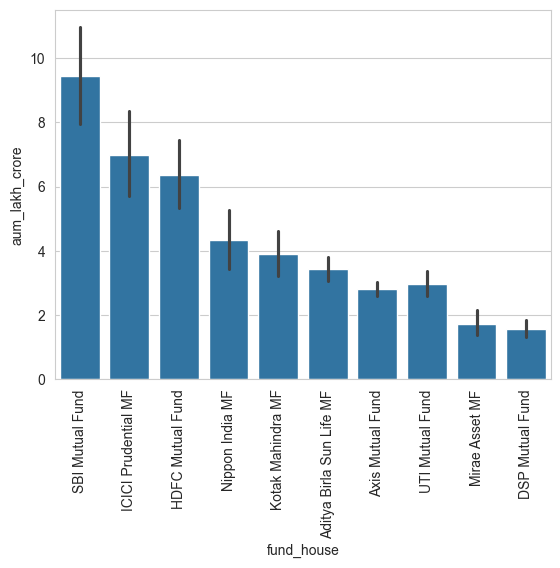

In [5]:
sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=90)

plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

Chart 3: SIP Trend

In [6]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow"
)

fig.show()

Chart 4: Category Inflow Heatmap

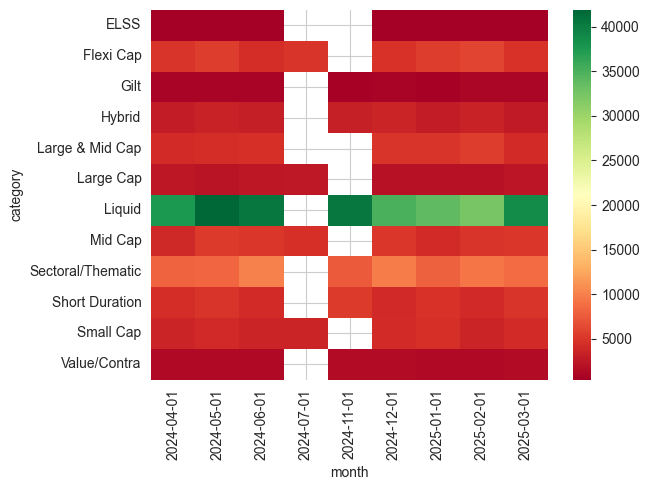

In [7]:
pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.show()

Chart 5: Age Group Distribution

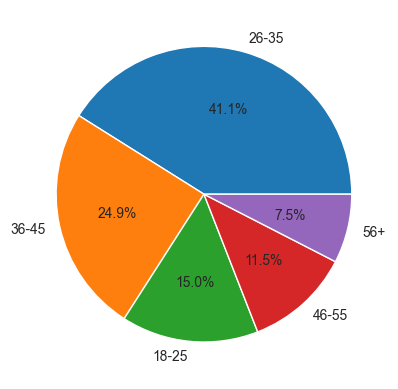

In [8]:
txn["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.show()

Chart 6: SIP Amount Boxplot

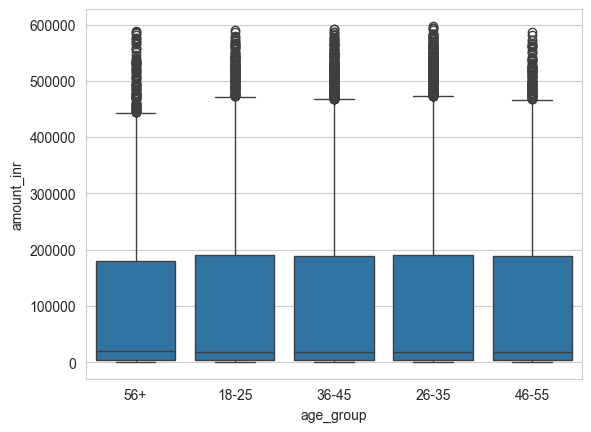

In [9]:
sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.show()

Chart 7: Gender Split

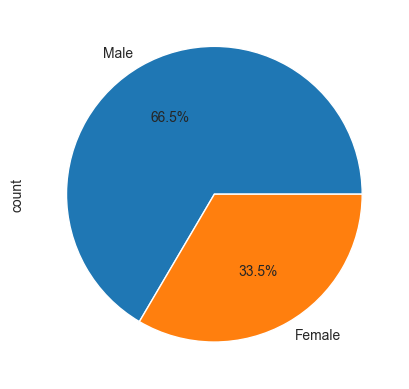

In [10]:
txn["gender"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.show()

Chart 8: State Distribution

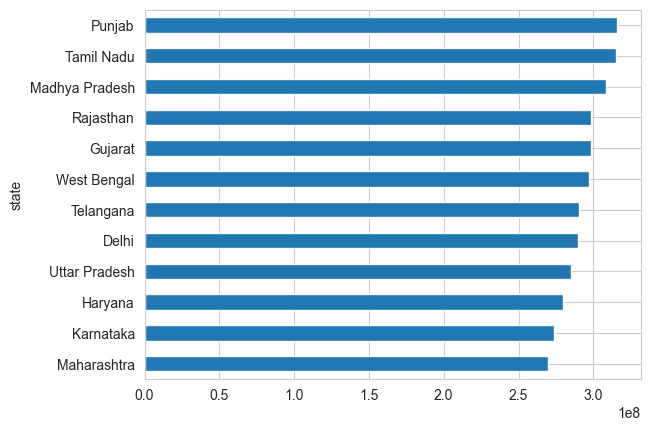

In [11]:
state_amt = (
    txn.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

state_amt.plot.barh()

plt.show()

Chart 9: T30 vs B30

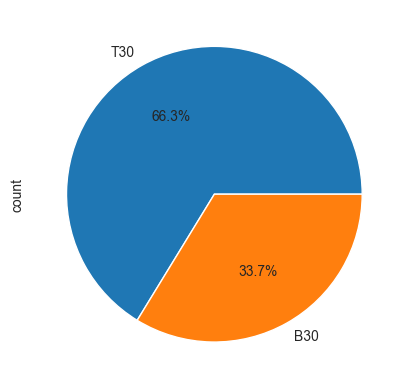

In [13]:
txn["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.show()

Chart 10: Folio Growth

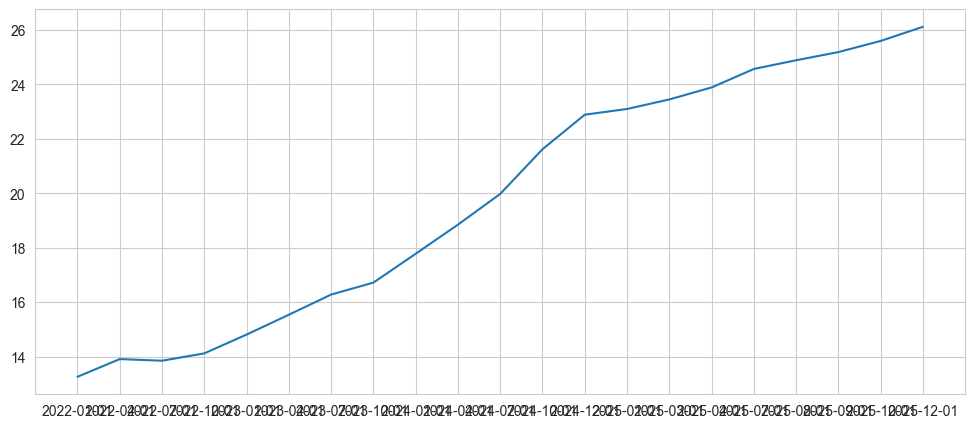

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.show()

Chart 11: Correlation Matrix

In [15]:
selected = (
    nav["amfi_code"]
    .unique()[:10]
)

In [16]:
corr_df = nav[
    nav["amfi_code"].isin(selected)
]

corr_df = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = corr_df.pct_change()

corr = returns.corr()

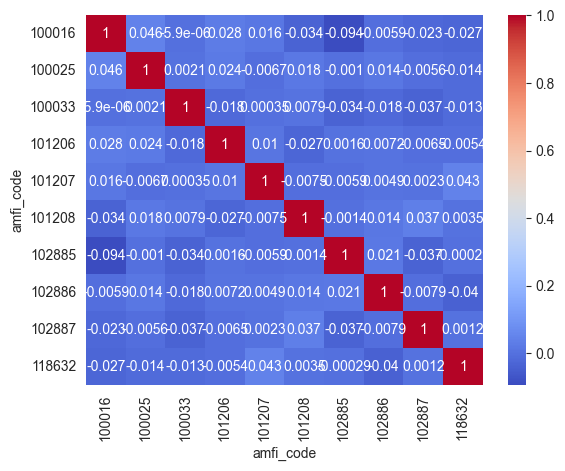

In [17]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Chart 12: Sector Allocation Donut

In [18]:
sector = (
    portfolio.groupby("sector")
    ["weight_pct"]
    .sum()
)

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5
)

fig.show()

In [19]:
for name, df in {
    "fund": fund,
    "nav": nav,
    "txn": txn,
    "perf": perf,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "portfolio": portfolio
}.items():
    print(name, df.shape)

fund (40, 15)
nav (46000, 3)
txn (32778, 13)
perf (40, 19)
aum (90, 5)
sip (48, 6)
category (143, 3)
folio (21, 6)
portfolio (322, 8)
